# Group 7 — Research Discovery & Collaboration Engine
## Week 3: Core NLP Model (Version 1 of the NLP Pipeline)
**SNLP Course Project 2026 · AI University Platform**

**Team:** E046 Chaitali Jaibhaye · E049 Himanshi Tripathi · E051 Durva Sawant · E052 Hida Rawal · E053 Dhanya Manam

**Task:** *Research text → Text representation → Similarity → Related researchers + Common topics*

This notebook implements:

| # | Component | Method |
|---|-----------|--------|
| 1 | Preprocessing | cleaning, lemmatisation (spaCy if available), stop-word removal |
| 2 | Baseline (Approach A) | TF-IDF + cosine similarity |
| 3 | Core model (Approach B) | Sentence-transformer document embeddings + cosine similarity |
| 4 | Keyword extraction | TF-IDF keywords and embedding-based (KeyBERT-style) keywords |
| 5 | Topic modelling | NMF over TF-IDF |
| 6 | NER / information extraction | spaCy NER + research-method lexicon matcher |
| 7 | Pipeline API | `find_related_researchers()` returns structured JSON |
| 8 | Evaluation | Precision@K, Recall@K, MRR for baseline vs embeddings vs hybrid |

> **Data note:** The Week 1–2 report said the real dataset was not finalised. This notebook ships with a small **synthetic sample** (fictional faculty) so the pipeline runs end to end. To use real data, drop a CSV at `data/faculty_research.csv` with the same columns (see Section 2) and the notebook will load it instead. **Numbers from the synthetic sample must not be reported as final results.**

## 1. Setup

In [ ]:
# Run once (Colab / local). Comment out if already installed.
# !pip install -q scikit-learn pandas numpy matplotlib sentence-transformers spacy
# !python -m spacy download en_core_web_sm

In [1]:
import os, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import NMF, TruncatedSVD
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Repo-relative paths (notebook lives in notebooks/, data in ../data, outputs in ../results)
ROOT = ".." if os.path.basename(os.getcwd()) == "notebooks" else "."
DATA_DIR, RESULTS_DIR = f"{ROOT}/data", f"{ROOT}/results"
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(RESULTS_DIR, exist_ok=True)
print("data dir:", os.path.abspath(DATA_DIR))

data dir: C:\Users\hp\Downloads\data


## 2. Dataset
Expected schema (one row per **paper**; faculty metadata repeated per row):

| Column | Description |
|---|---|
| `faculty_id` | unique id |
| `faculty_name` | name |
| `department` | department |
| `research_interests` | free-text interests |
| `paper_title`, `abstract`, `keywords` | publication data |
| `areas` | **evaluation label**: `;`-separated research areas, manually validated by the team |

The `areas` column is what we use to decide which researcher pairs are truly *related* (ground truth). With real data, the team should assign these by hand (and ideally have two annotators).

In [4]:
SAMPLE = [
# (id, name, dept, interests, areas, [(title, abstract, keywords), ...])
("F01","Faculty A","Computer Science","natural language processing, information extraction, named entity recognition","NLP",
 [("Transformer-based Named Entity Recognition for Low-Resource Domains","We fine-tune BERT for named entity recognition in low-resource domains and study annotation efficiency.","NER; BERT; transformers; low-resource"),
  ("Relation Extraction from Scientific Text","We propose a neural pipeline for extracting relations between methods and tasks in scientific text.","information extraction; relation extraction; scientific text")]),
("F02","Faculty B","Computer Science","knowledge graphs, entity linking, semantic web, information extraction","KG;NLP",
 [("Entity Linking for Knowledge Graph Population","We link extracted mentions to knowledge graph entities using contextual embeddings.","entity linking; knowledge graph; embeddings"),
  ("Automatic Knowledge Graph Construction from Text","A pipeline combining named entity recognition and relation extraction builds a knowledge graph from documents.","knowledge graph; information extraction; NER")]),
("F03","Faculty C","Computer Science","ontology engineering, knowledge graph construction, semantic search","KG",
 [("Ontology-driven Semantic Search over Academic Data","We design an ontology and a SPARQL-based semantic search system for university data.","ontology; semantic search; SPARQL"),
  ("Graph Embeddings for Link Prediction in Knowledge Graphs","We evaluate translation-based graph embeddings for link prediction on knowledge graphs.","knowledge graph; graph embeddings; link prediction")]),
("F04","Faculty D","Computer Science","large language models, generative AI, retrieval augmented generation","NLP",
 [("Retrieval-Augmented Generation for Question Answering","We combine dense retrieval with large language models to answer domain questions with citations.","RAG; LLM; dense retrieval; question answering"),
  ("Reducing Hallucination in Generative AI Systems","We study prompting and grounding strategies that reduce hallucination in large language models.","hallucination; generative AI; LLM; grounding")]),
("F05","Faculty E","Computer Science","multimodal learning, vision-language models, generative AI","CV;NLP",
 [("Vision-Language Pretraining for Image Captioning","We pretrain a transformer on paired images and text to generate captions.","vision-language; transformers; image captioning"),
  ("Text-to-Image Generative Models: A Survey","This survey reviews diffusion-based generative AI models that synthesise images from text prompts.","generative AI; diffusion; text-to-image")]),
("F06","Faculty F","Electronics","image segmentation, object detection, deep learning for medical imaging","CV;HEALTH",
 [("U-Net Variants for Tumour Segmentation in MRI","We compare convolutional segmentation networks for brain tumour segmentation in MRI scans.","segmentation; U-Net; MRI; deep learning"),
  ("Object Detection with Lightweight Convolutional Networks","We propose a lightweight CNN detector for real-time object detection on embedded devices.","object detection; CNN; real-time")]),
("F07","Faculty G","Electronics","video analytics, object tracking, convolutional neural networks","CV",
 [("Multi-Object Tracking in Surveillance Video","We present a tracking-by-detection method with appearance embeddings for crowded video scenes.","object tracking; video analytics; re-identification"),
  ("Action Recognition using 3D Convolutional Networks","A 3D CNN architecture is trained for human action recognition in videos.","action recognition; 3D CNN; video")]),
("F08","Faculty H","Health Informatics","clinical text mining, electronic health records, biomedical NLP","HEALTH;NLP",
 [("Clinical Named Entity Recognition in Electronic Health Records","We adapt transformer models to extract diseases and medications from clinical notes.","clinical NER; EHR; transformers; biomedical NLP"),
  ("Summarising Discharge Summaries with Language Models","We evaluate abstractive summarisation of hospital discharge summaries with factual consistency checks.","summarisation; clinical text; factual consistency")]),
("F09","Faculty I","Health Informatics","medical imaging diagnosis, disease prediction, machine learning in healthcare","HEALTH;CV",
 [("Deep Learning for Chest X-ray Diagnosis","We train convolutional networks to detect pneumonia from chest X-ray images.","chest X-ray; diagnosis; deep learning; CNN"),
  ("Predicting Diabetes Risk from Patient Records","We compare gradient boosting and logistic regression for disease risk prediction on patient records.","disease prediction; machine learning; healthcare")]),
("F10","Faculty J","Information Technology","network intrusion detection, cybersecurity, anomaly detection","SEC",
 [("Anomaly-based Network Intrusion Detection using Autoencoders","We detect network intrusions with autoencoders trained on benign traffic.","intrusion detection; anomaly detection; autoencoder"),
  ("Adversarial Attacks on Malware Classifiers","We analyse how adversarial perturbations evade machine-learning malware classifiers.","adversarial attacks; malware; cybersecurity")]),
("F11","Faculty K","Information Technology","internet of things, edge computing, secure wireless sensor networks","SEC;IOT",
 [("Lightweight Authentication for IoT Edge Devices","We propose a lightweight authentication protocol for resource-constrained IoT devices.","IoT; authentication; edge computing; security"),
  ("Energy-Efficient Routing in Wireless Sensor Networks","We design an energy-aware routing protocol that extends wireless sensor network lifetime.","wireless sensor networks; routing; energy efficiency")]),
("F12","Faculty L","Information Technology","smart campus sensing, IoT analytics, time series forecasting","IOT",
 [("Smart Campus Energy Monitoring using IoT Sensors","We deploy IoT sensors across a campus and forecast building energy consumption.","smart campus; IoT; energy; time series"),
  ("LSTM-based Forecasting of Sensor Time Series","We compare LSTM and ARIMA models for forecasting multivariate sensor time series.","LSTM; time series forecasting; sensors")]),
]
rows = [dict(faculty_id=i, faculty_name=n, department=d, research_interests=ri, areas=a,
             paper_title=t, abstract=ab, keywords=kw)
        for i,n,d,ri,a,papers in SAMPLE for t,ab,kw in papers]
REAL_CSV = f"{DATA_DIR}/faculty_research.csv"
if os.path.exists(REAL_CSV):
    df = pd.read_csv(REAL_CSV); DATA_SOURCE = "REAL"
else:
    df = pd.DataFrame(rows); df.to_csv(f"{DATA_DIR}/sample_faculty_research.csv", index=False); DATA_SOURCE = "SYNTHETIC SAMPLE"
print(f"Data source: {DATA_SOURCE} | rows: {len(df)} | faculty: {df.faculty_id.nunique()}")
df.head(3)

Data source: SYNTHETIC SAMPLE | rows: 24 | faculty: 12


,faculty_id,faculty_name,department,research_interests,areas,paper_title,abstract,keywords
0,F01,Faculty A,Computer Science,"natural language processing, information extra...",NLP,Transformer-based Named Entity Recognition for...,We fine-tune BERT for named entity recognition...,NER; BERT; transformers; low-resource
1,F01,Faculty A,Computer Science,"natural language processing, information extra...",NLP,Relation Extraction from Scientific Text,We propose a neural pipeline for extracting re...,information extraction; relation extraction; s...
2,F02,Faculty B,Computer Science,"knowledge graphs, entity linking, semantic web...",KG;NLP,Entity Linking for Knowledge Graph Population,We link extracted mentions to knowledge graph ...,entity linking; knowledge graph; embeddings


## 3. Preprocessing

In [7]:
# spaCy is optional: used for lemmatisation and NER. Falls back to regex if unavailable.
try:
    import spacy
    nlp = spacy.load("en_core_web_sm"); HAS_SPACY = True
except Exception as e:
    nlp, HAS_SPACY = None, False
    print("spaCy model not available -> regex fallback (install en_core_web_sm for full NER).")

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
STOP = set(ENGLISH_STOP_WORDS) | {"propose","present","study","paper","approach","using","use","based","evaluate","compare","novel","method","show"}

def preprocess(text: str) -> str:
    """Lowercase, strip non-alphanumerics, lemmatise (if spaCy), drop stop-words."""
    text = re.sub(r"[^A-Za-z0-9\-\s]", " ", str(text))
    if HAS_SPACY:
        toks = [t.lemma_.lower() for t in nlp(text) if not t.is_space]
    else:
        toks = [t.lower() for t in text.split()]
    return " ".join(t for t in toks if t not in STOP and len(t) > 1)

print(preprocess("We fine-tune BERT for named entity recognition in low-resource domains."))

spaCy model not available -> regex fallback (install en_core_web_sm for full NER).
fine-tune bert named entity recognition low-resource domains


### Build one document per researcher
Each researcher profile = research interests + all paper titles + abstracts + keywords. (Keywords and interests are repeated once to give curated terms slightly more weight.)

In [10]:
def build_profile(g):
    parts = [g.research_interests.iloc[0], g.research_interests.iloc[0]]
    for _, r in g.iterrows():
        parts += [r.paper_title, r.abstract, str(r.keywords).replace(";", ","), str(r.keywords).replace(";", ",")]
    return " . ".join(parts)

profiles = (df.groupby("faculty_id")
              .apply(lambda g: pd.Series({
                  "faculty_name": g.faculty_name.iloc[0],
                  "department": g.department.iloc[0],
                  "areas": set(a.strip() for a in g.areas.iloc[0].split(";")),
                  "raw_text": build_profile(g)}))
              .reset_index())
profiles["clean_text"] = profiles.raw_text.apply(preprocess)
ids = profiles.faculty_id.tolist()
name_of = dict(zip(profiles.faculty_id, profiles.faculty_name))
print(len(profiles), "researcher profiles")
profiles[["faculty_id","faculty_name","department"]].head()

12 researcher profiles


,faculty_id,faculty_name,department
0,F01,Faculty A,Computer Science
1,F02,Faculty B,Computer Science
2,F03,Faculty C,Computer Science
3,F04,Faculty D,Computer Science
4,F05,Faculty E,Computer Science


## 4. Baseline (Approach A): TF-IDF + Cosine Similarity

In [13]:
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=1, sublinear_tf=True)
X_tfidf = tfidf.fit_transform(profiles.clean_text)
S_tfidf = cosine_similarity(X_tfidf)
np.fill_diagonal(S_tfidf, 0)           # a researcher is not related to themself
print("TF-IDF matrix:", X_tfidf.shape)

TF-IDF matrix: (12, 663)


## 5. Core Model (Approach B): Document Embeddings + Semantic Similarity
Uses `sentence-transformers/all-MiniLM-L6-v2`. If the model cannot be downloaded (offline / no package), the notebook falls back to **LSA** (TF-IDF → SVD) so the pipeline still runs. **Check the printed message: the reported results are only "embedding" results if `EMBEDDER = sentence-transformer`.**

In [16]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
try:
    from sentence_transformers import SentenceTransformer
    st_model = SentenceTransformer(MODEL_NAME)
    def embed(texts):
        return np.asarray(st_model.encode(list(texts), normalize_embeddings=True, show_progress_bar=False))
    EMBEDDER = "sentence-transformer"
except Exception as e:
    print("sentence-transformers unavailable -> LSA fallback.", type(e).__name__)
    _svd = TruncatedSVD(n_components=min(8, X_tfidf.shape[0]-1), random_state=RANDOM_STATE).fit(X_tfidf)
    def embed(texts):
        v = _svd.transform(tfidf.transform([preprocess(t) for t in texts]))
        return v / (np.linalg.norm(v, axis=1, keepdims=True) + 1e-12)
    EMBEDDER = "LSA-fallback"
print("EMBEDDER =", EMBEDDER)

# Embed the raw (lightly cleaned) profile text: transformers benefit from natural sentences
E = embed(profiles.raw_text.tolist())
S_emb = cosine_similarity(E); np.fill_diagonal(S_emb, 0)

# Hybrid: weighted blend of lexical + semantic similarity
ALPHA = 0.5
S_hyb = ALPHA * S_emb + (1 - ALPHA) * S_tfidf
print("Embedding matrix:", E.shape)

sentence-transformers unavailable -> LSA fallback. ModuleNotFoundError
EMBEDDER = LSA-fallback
Embedding matrix: (12, 8)


## 6. Keyword Extraction

In [19]:
def tfidf_keywords(idx, top_n=10):
    row = X_tfidf[idx].toarray().ravel()
    terms = np.array(tfidf.get_feature_names_out())
    return list(terms[row.argsort()[::-1][:top_n]])

def embedding_keywords(idx, top_n=10):
    """KeyBERT-style: rank candidate n-grams by cosine similarity to the profile embedding."""
    cands = [c for c in tfidf_keywords(idx, 40) if len(c) > 2]
    if not cands: return []
    ce = embed(cands)
    sims = ce @ E[idx]
    return [cands[i] for i in np.argsort(-sims)[:top_n]]

i0 = ids.index("F02")
print("TF-IDF keywords     :", tfidf_keywords(i0))
print("Embedding keywords  :", embedding_keywords(i0))

TF-IDF keywords     : ['knowledge', 'graph', 'knowledge graph', 'entity linking', 'linking', 'extraction', 'entity', 'linking knowledge', 'information extraction', 'information']
Embedding keywords  : ['graph information', 'linking', 'web', 'combining', 'automatic', 'mentions', 'contextual', 'entities', 'extraction knowledge', 'graphs entity']


## 7. Topic Modelling (NMF)

In [22]:
N_TOPICS = 6
cv = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9, sublinear_tf=True)
Xt = cv.fit_transform(profiles.clean_text)
nmf = NMF(n_components=N_TOPICS, random_state=RANDOM_STATE, init="nndsvda", max_iter=500)
W = nmf.fit_transform(Xt)                                   # researcher x topic
W = W / (W.sum(1, keepdims=True) + 1e-12)                   # normalise to a distribution
terms = np.array(cv.get_feature_names_out())
topic_words = [list(terms[c.argsort()[::-1][:6]]) for c in nmf.components_]
for t, w in enumerate(topic_words): print(f"Topic {t}: {', '.join(w)}")

Topic 0: text, ner, entity, named, named entity, entity recognition
Topic 1: object, cnn, deep, deep learning, convolutional, learning
Topic 2: graph, knowledge, knowledge graph, semantic, graph embeddings, embeddings
Topic 3: iot, energy, sensor, time, networks, analytics
Topic 4: generative, ai, generative ai, models, language, language models
Topic 5: detection, network, machine, machine learning, detect, trained


## 8. NER & Information Extraction
Two complementary extractors: (1) spaCy's general NER (ORG / PRODUCT / etc.), and (2) a **research-method lexicon matcher** for domain concepts that a general NER model does not know (e.g. *Transformer*, *BERT*, *CNN*). A fine-tuned scientific NER model (e.g. SciSpaCy) is planned for Week 4.

In [25]:
METHOD_LEXICON = ["transformer","bert","cnn","lstm","gan","diffusion","autoencoder","u-net","gradient boosting",
    "logistic regression","large language model","llm","rag","retrieval-augmented generation","knowledge graph",
    "ontology","graph embedding","named entity recognition","relation extraction","entity linking","time series"]
_pat = re.compile(r"\b(" + "|".join(re.escape(m) for m in sorted(METHOD_LEXICON, key=len, reverse=True)) + r")\b", re.I)

def extract_entities(text):
    methods = sorted({m.lower() for m in _pat.findall(text)})
    general = sorted({(e.text, e.label_) for e in nlp(text).ents}) if HAS_SPACY else []
    return {"methods_and_concepts": methods, "named_entities": [list(x) for x in general]}

print(extract_entities(profiles.raw_text[i0]))

{'methods_and_concepts': ['entity linking', 'knowledge graph', 'named entity recognition', 'relation extraction'], 'named_entities': []}


## 9. Pipeline: `find_related_researchers()`
Returns the structured JSON expected by the project handout (related researchers + similarity + common topics), plus **explainability** (shared keywords / shared topics) so users see *why* two researchers were matched.

In [28]:
SIM = {"tfidf": S_tfidf, "embedding": S_emb, "hybrid": S_hyb}

def _shared_topics(i, j, top=3):
    overlap = np.minimum(W[i], W[j])
    return [ {"topic_id": int(t), "top_terms": topic_words[t][:4], "strength": round(float(overlap[t]),3)}
             for t in overlap.argsort()[::-1][:top] if overlap[t] > 0.05 ]

def find_related_researchers(faculty_id: str, k: int = 3, method: str = "hybrid") -> dict:
    """Core Week-3 API function. method in {'tfidf','embedding','hybrid'}."""
    if faculty_id not in ids: raise ValueError(f"Unknown faculty_id {faculty_id}")
    if method not in SIM: raise ValueError(f"method must be one of {list(SIM)}")
    i = ids.index(faculty_id)
    order = np.argsort(-SIM[method][i])[:k]
    kw_i = set(tfidf_keywords(i, 25))
    related = []
    for j in order:
        related.append({
            "faculty_id": ids[j], "faculty_name": name_of[ids[j]],
            "department": profiles.department[j],
            "similarity": round(float(SIM[method][i, j]), 3),
            "shared_keywords": sorted(kw_i & set(tfidf_keywords(j, 25)))[:6],
            "shared_topics": _shared_topics(i, j)})
    return {"input_id": faculty_id, "method": method, "embedder": EMBEDDER,
            "result": {"researcher": name_of[faculty_id],
                       "top_keywords": embedding_keywords(i, 6),
                       "entities": extract_entities(profiles.raw_text[i])["methods_and_concepts"],
                       "related_researchers": related}}

print(json.dumps(find_related_researchers("F02", k=3), indent=2))

{
  "input_id": "F02",
  "method": "hybrid",
  "embedder": "LSA-fallback",
  "result": {
    "researcher": "Faculty B",
    "top_keywords": [
      "graph information",
      "linking",
      "web",
      "combining",
      "automatic",
      "mentions"
    ],
    "entities": [
      "entity linking",
      "knowledge graph",
      "named entity recognition",
      "relation extraction"
    ],
    "related_researchers": [
      {
        "faculty_id": "F03",
        "faculty_name": "Faculty C",
        "department": "Computer Science",
        "similarity": 0.531,
        "shared_keywords": [
          "embeddings",
          "graph",
          "graph embeddings",
          "knowledge",
          "knowledge graph",
          "knowledge graphs"
        ],
        "shared_topics": [
          {
            "topic_id": 2,
            "top_terms": [
              "graph",
              "knowledge",
              "knowledge graph",
              "semantic"
            ],
            "streng

## 10. Evaluation: Baseline vs Embeddings vs Hybrid
**Ground truth:** two researchers are *related* if they share at least one label in `areas`.
Metrics: **Precision@K**, **Recall@K**, **MRR** (mean reciprocal rank of the first relevant researcher), averaged over all researchers.

> ⚠️ With the synthetic sample the labels were written by us together with the data, so scores will be optimistic. Re-run on the real, manually validated dataset for reportable numbers.

In [31]:
areas = profiles.areas.tolist()
REL = np.array([[bool(areas[i] & areas[j]) and i != j for j in range(len(ids))] for i in range(len(ids))])

def evaluate(S, k=3):
    P, R, RR = [], [], []
    for i in range(len(ids)):
        if REL[i].sum() == 0: continue
        order = np.argsort(-S[i]); order = order[order != i]
        hits = REL[i][order]
        P.append(hits[:k].sum() / k)
        R.append(hits[:k].sum() / REL[i].sum())
        RR.append(1 / (np.argmax(hits) + 1) if hits.any() else 0)
    return {f"P@{k}": np.mean(P), f"R@{k}": np.mean(R), "MRR": np.mean(RR)}

results = pd.DataFrame({m: {**evaluate(S, 1), **evaluate(S, 3), **evaluate(S, 5)} for m, S in SIM.items()}).T
results = results.loc[:, ["P@1","P@3","R@3","P@5","R@5","MRR"]].round(3)
results.to_csv(f"{RESULTS_DIR}/week3_baseline_vs_embedding.csv")
results

,P@1,P@3,R@3,P@5,R@5,MRR
tfidf,0.917,0.667,0.600,0.567,0.855,0.938
embedding,0.917,0.528,0.495,0.433,0.610,0.929
hybrid,0.917,0.528,0.495,0.450,0.693,0.933


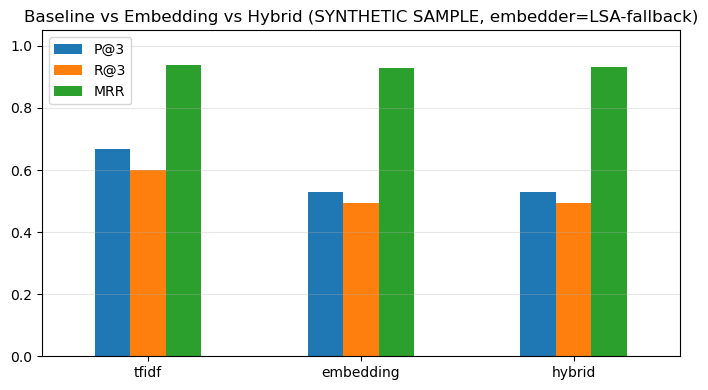

In [33]:
ax = results[["P@3","R@3","MRR"]].plot(kind="bar", figsize=(7,4), rot=0)
ax.set_title(f"Baseline vs Embedding vs Hybrid ({DATA_SOURCE}, embedder={EMBEDDER})")
ax.set_ylim(0, 1.05); ax.grid(axis="y", alpha=.3); plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week3_comparison.png", dpi=150); plt.show()

### Quick error look (feeds Week 5 error analysis)

In [36]:
errors = []
for i in range(len(ids)):
    top = np.argsort(-S_hyb[i])[:3]
    for j in top:
        if not REL[i, j]:
            errors.append({"query": name_of[ids[i]], "wrong_match": name_of[ids[j]],
                           "score": round(float(S_hyb[i, j]), 3),
                           "shared_keywords": sorted(set(tfidf_keywords(i,25)) & set(tfidf_keywords(j,25)))[:5]})
err_df = pd.DataFrame(errors).sort_values("score", ascending=False)
err_df.to_csv(f"{RESULTS_DIR}/week3_error_candidates.csv", index=False)
print(len(err_df), "top-3 false positives (hybrid)")
err_df.head(8)

17 top-3 false positives (hybrid)


,query,wrong_match,score,shared_keywords
0,Faculty A,Faculty K,0.147,[]
13,Faculty K,Faculty A,0.147,[]
15,Faculty L,Faculty H,0.131,[]
8,Faculty H,Faculty L,0.131,[]
5,Faculty F,Faculty K,0.126,[]
14,Faculty K,Faculty F,0.126,[]
1,Faculty C,Faculty I,0.087,[prediction]
9,Faculty I,Faculty C,0.087,[prediction]


## 11. Save Outputs

In [39]:
demo = {fid: find_related_researchers(fid, k=3) for fid in ids}
with open(f"{RESULTS_DIR}/week3_sample_outputs.json", "w") as f:
    json.dump(demo, f, indent=2)
print("Saved: results/week3_baseline_vs_embedding.csv, week3_comparison.png, week3_error_candidates.csv, week3_sample_outputs.json")

Saved: results/week3_baseline_vs_embedding.csv, week3_comparison.png, week3_error_candidates.csv, week3_sample_outputs.json


## 12. Week 3 Summary & Next Steps
**Done in this notebook:** preprocessing, researcher-profile construction, TF-IDF baseline, embedding-based similarity, hybrid ranking, keyword extraction, NMF topics, NER + method lexicon, structured-JSON pipeline function, first quantitative comparison.

**Before Week 4:**
1. Replace the synthetic sample with the **real dataset** (`data/faculty_research.csv`) and re-run.
2. Have two team members independently label related pairs; report agreement.
3. Tune `ALPHA`, `N_TOPICS`, keyword count; try SPECTER / SciBERT embeddings.
4. Upgrade NER (SciSpaCy) and start the Research Knowledge Graph (stretch goal).
5. Wrap `find_related_researchers` in FastAPI (`POST /find-related-researchers`) for Week 6.